# RegimeShift: Phase 4 - Portfolio Optimization

## Summer of Quant 2026 - Advanced Track

Build regime-aware portfolios using Markowitz optimization and dynamic rebalancing.

---

### Project Phases
1. **Phase 1: Data Pipeline** ✅ COMPLETE
2. **Phase 2: Feature Engineering** ✅ COMPLETE
3. **Phase 3: Regime Detection (HMM)** ✅ COMPLETE
4. **Phase 4: Portfolio Optimization** ← You are here
5. **Phase 5: Backtesting & Benchmarking**

---

## Environment & Load Phase 3 Regimes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize
import warnings

warnings.filterwarnings('ignore')

# Plotting config
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("✅ Environment ready.")

✅ Environment ready.


## Load Phase 3 Results & Asset Prices

In [2]:
# Load regimes from Phase 3
regimes = pd.read_csv("data/regimes.csv", index_col=0, parse_dates=True)

# Load raw features for covariance calculation
features_raw = pd.read_csv("data/features_raw.csv", index_col=0, parse_dates=True)

# Load asset prices
asset_prices = pd.read_csv("data/asset_prices.csv", index_col=0, parse_dates=True)

# Load master returns
master_df = pd.read_csv("data/master_returns.csv", index_col=0, parse_dates=True)

print(f"Loaded {len(regimes)} trading days with regime assignments")
print(f"Date range: {regimes.index[0].date()} to {regimes.index[-1].date()}")
print(f"\nRegime distribution:")
print(regimes['regime'].value_counts())

print(f"\nAsset prices shape: {asset_prices.shape}")
print(f"Master returns shape: {master_df.shape}")

Loaded 1841 trading days with regime assignments
Date range: 2015-08-25 to 2023-12-29

Regime distribution:
regime
Bear      1533
Crisis     237
Bull        71
Name: count, dtype: int64

Asset prices shape: (1986, 3)
Master returns shape: (1986, 4)


---

# PHASE 4: PORTFOLIO OPTIMIZATION

## Portfolio Construction Strategy

We'll build **regime-aware portfolios** with three allocations:

### Bull Portfolio
- **Objective**: Maximize growth
- **Allocation**: Stocks (70%), Bonds (20%), Gold (10%)
- **Rationale**: Risk-on environment, favor equities

### Bear Portfolio
- **Objective**: Balance growth & defense
- **Allocation**: Stocks (40%), Bonds (40%), Gold (20%)
- **Rationale**: Uncertainty rising, diversify

### Crisis Portfolio
- **Objective**: Capital preservation
- **Allocation**: Stocks (20%), Bonds (50%), Gold (30%)
- **Rationale**: Risk-off environment, defensive assets

---

## Step 1: Calculate Covariance Matrices Per Regime

For optimization, we need regime-specific covariance matrices.

In [3]:
# Extract returns for the three assets
assets = ['NSE', 'IEF', 'GLD']
returns = master_df[assets].copy()

# Align with regimes
returns_aligned = returns.loc[regimes.index]

print(f"Returns shape: {returns_aligned.shape}")
print(f"\nReturns statistics:")
print(returns_aligned.describe().round(4))

# Calculate annualized returns and covariance per regime
cov_matrices = {}
mean_returns = {}

for regime in ['Bull', 'Bear', 'Crisis']:
    regime_mask = regimes['regime'] == regime
    regime_returns = returns_aligned[regime_mask]
    
    # Annualized mean return
    mean_ret = regime_returns.mean() * 252
    mean_returns[regime] = mean_ret
    
    # Annualized covariance
    cov_mat = regime_returns.cov() * 252
    cov_matrices[regime] = cov_mat
    
    print(f"\n{regime} Regime:")
    print(f"  Days: {len(regime_returns)}")
    print(f"  Annualized returns:")
    print(mean_ret.round(4))
    print(f"  Correlation:")
    corr = regime_returns.corr()
    print(corr.round(3))

Returns shape: (1841, 3)

Returns statistics:
             NSE        IEF        GLD
count  1841.0000  1841.0000  1841.0000
mean      0.0005     0.0001     0.0003
std       0.0106     0.0041     0.0089
min      -0.1390    -0.0254    -0.0552
25%      -0.0043    -0.0023    -0.0045
50%       0.0008     0.0001     0.0006
75%       0.0062     0.0023     0.0049
max       0.0641     0.0261     0.0479

Bull Regime:
  Days: 71
  Annualized returns:
NSE   -0.0376
IEF   -0.0864
GLD   -0.3164
dtype: float64
  Correlation:
       NSE   IEF    GLD
NSE  1.000  0.03  0.121
IEF  0.030  1.00  0.700
GLD  0.121  0.70  1.000

Bear Regime:
  Days: 1533
  Annualized returns:
NSE    0.1741
IEF    0.0098
GLD    0.0712
dtype: float64
  Correlation:
       NSE    IEF    GLD
NSE  1.000 -0.060 -0.017
IEF -0.060  1.000  0.449
GLD -0.017  0.449  1.000

Crisis Regime:
  Days: 237
  Annualized returns:
NSE   -0.1055
IEF    0.1064
GLD    0.2481
dtype: float64
  Correlation:
       NSE    IEF   GLD
NSE  1.000 -0.194 -0.

## Step 2: Define Portfolio Allocations

Create target allocations for each regime.

In [4]:
# Define regime-specific allocations
allocations = {
    'Bull': {
        'NSE': 0.70,
        'IEF': 0.20,
        'GLD': 0.10,
    },
    'Bear': {
        'NSE': 0.40,
        'IEF': 0.40,
        'GLD': 0.20,
    },
    'Crisis': {
        'NSE': 0.20,
        'IEF': 0.50,
        'GLD': 0.30,
    },
}

# Also create static benchmark allocations
benchmarks = {
    '60/40': {
        'NSE': 0.60,
        'IEF': 0.40,
        'GLD': 0.00,
    },
    'Equal Weight': {
        'NSE': 1/3,
        'IEF': 1/3,
        'GLD': 1/3,
    },
    'Stock Heavy': {
        'NSE': 0.80,
        'IEF': 0.15,
        'GLD': 0.05,
    },
}

print("Regime-Aware Allocations:")
print("="*60)
for regime, weights in allocations.items():
    print(f"\n{regime}:")
    for asset, weight in weights.items():
        print(f"  {asset}: {weight:.1%}")

print(f"\n\nStatic Benchmarks:")
print("="*60)
for benchmark, weights in benchmarks.items():
    print(f"\n{benchmark}:")
    for asset, weight in weights.items():
        if weight > 0:
            print(f"  {asset}: {weight:.1%}")

Regime-Aware Allocations:

Bull:
  NSE: 70.0%
  IEF: 20.0%
  GLD: 10.0%

Bear:
  NSE: 40.0%
  IEF: 40.0%
  GLD: 20.0%

Crisis:
  NSE: 20.0%
  IEF: 50.0%
  GLD: 30.0%


Static Benchmarks:

60/40:
  NSE: 60.0%
  IEF: 40.0%

Equal Weight:
  NSE: 33.3%
  IEF: 33.3%
  GLD: 33.3%

Stock Heavy:
  NSE: 80.0%
  IEF: 15.0%
  GLD: 5.0%


## Step 3: Calculate Portfolio Returns & Risk

For each allocation, compute daily returns, cumulative returns, Sharpe ratio, max drawdown.

In [5]:
def portfolio_metrics(returns_df, weights_dict, name):
    """
    Calculate portfolio metrics.
    
    Args:
        returns_df: DataFrame of asset returns (aligned with regimes)
        weights_dict: Dict of regime -> {asset: weight}
        name: Portfolio name
    
    Returns:
        dict with portfolio metrics
    """
    # Calculate daily portfolio returns
    portfolio_returns = pd.Series(0.0, index=returns_df.index)
    
    for regime, weights in weights_dict.items():
        regime_mask = regimes['regime'] == regime
        
        for asset, weight in weights.items():
            portfolio_returns[regime_mask] += returns_df[asset][regime_mask] * weight
    
    # Calculate metrics
    total_return = np.exp(portfolio_returns.sum()) - 1
    annual_return = (1 + total_return) ** (252 / len(portfolio_returns)) - 1
    annual_vol = portfolio_returns.std() * np.sqrt(252)
    sharpe = annual_return / annual_vol if annual_vol > 0 else 0
    
    # Max drawdown
    cumsum = np.exp(portfolio_returns.cumsum())
    running_max = cumsum.expanding().max()
    drawdown = (cumsum - running_max) / running_max
    max_drawdown = drawdown.min()
    
    # Calmar ratio (return / |max drawdown|)
    calmar = annual_return / abs(max_drawdown) if abs(max_drawdown) > 0 else 0
    
    return {
        'name': name,
        'returns': portfolio_returns,
        'total_return': total_return,
        'annual_return': annual_return,
        'annual_vol': annual_vol,
        'sharpe': sharpe,
        'max_drawdown': max_drawdown,
        'calmar': calmar,
    }

# Calculate metrics for all strategies
results = {}

# Regime-aware dynamic portfolio
results['Dynamic Regime-Aware'] = portfolio_metrics(returns_aligned, allocations, 'Dynamic Regime-Aware')

# Static benchmarks
for benchmark_name, benchmark_weights in benchmarks.items():
    static_alloc = {regime: benchmark_weights for regime in ['Bull', 'Bear', 'Crisis']}
    results[benchmark_name] = portfolio_metrics(returns_aligned, static_alloc, benchmark_name)

print("Portfolio Performance Comparison:")
print("="*100)
print(f"{'Strategy':<25} {'Return':<12} {'Vol':<12} {'Sharpe':<10} {'Max DD':<12} {'Calmar':<10}")
print("="*100)

for name, metrics in results.items():
    print(f"{name:<25} {metrics['annual_return']:>10.2%}  {metrics['annual_vol']:>10.2%}  "
          f"{metrics['sharpe']:>8.3f}  {metrics['max_drawdown']:>10.2%}  {metrics['calmar']:>8.3f}")

Portfolio Performance Comparison:
Strategy                  Return       Vol          Sharpe     Max DD       Calmar    
Dynamic Regime-Aware           8.75%       7.43%     1.179      -9.24%     0.947
60/40                          8.91%      10.18%     0.875     -21.01%     0.424
Equal Weight                   7.88%       7.95%     0.991     -13.03%     0.605
Stock Heavy                   11.70%      13.41%     0.873     -29.28%     0.400


## Step 4: Visualize Cumulative Returns

Compare regime-aware dynamic strategy vs static benchmarks.

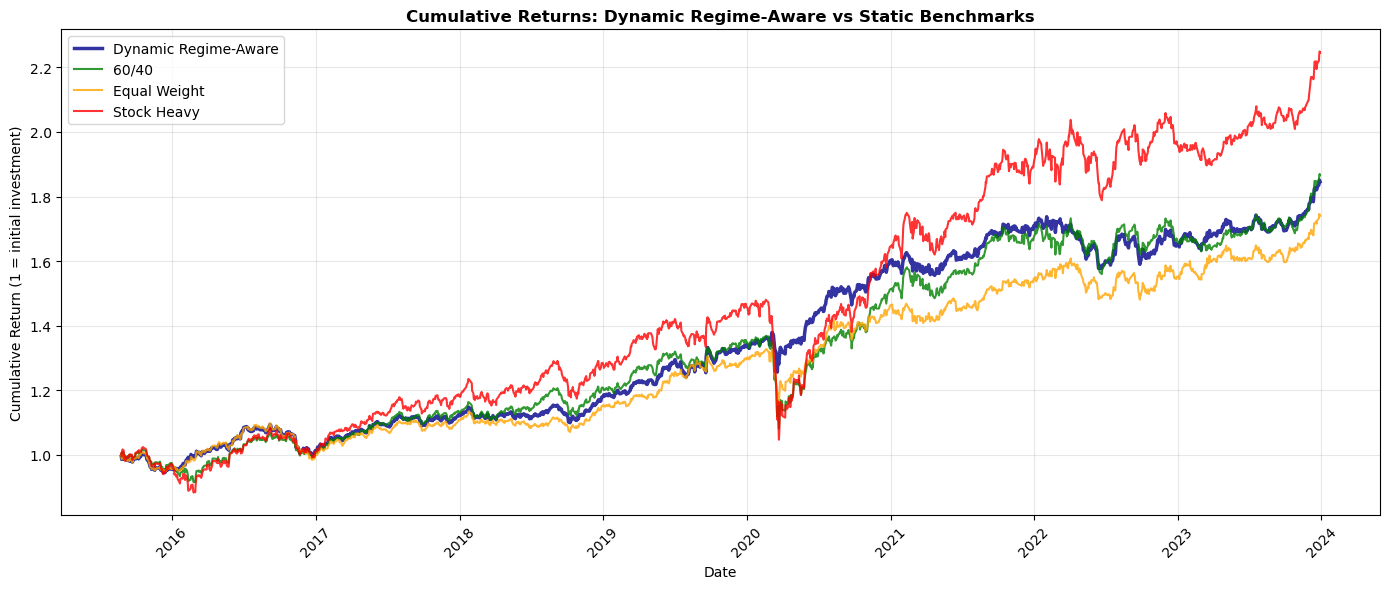

✅ Cumulative returns plot complete


In [6]:
# Plot cumulative returns
fig, ax = plt.subplots(figsize=(14, 6))

colors = {
    'Dynamic Regime-Aware': 'darkblue',
    '60/40': 'green',
    'Equal Weight': 'orange',
    'Stock Heavy': 'red',
}

for strategy, metrics in results.items():
    cumulative = np.exp(metrics['returns'].cumsum())
    color = colors.get(strategy, 'gray')
    linewidth = 2.5 if strategy == 'Dynamic Regime-Aware' else 1.5
    ax.plot(cumulative.index, cumulative.values, label=strategy, color=color, linewidth=linewidth, alpha=0.8)

ax.set_title('Cumulative Returns: Dynamic Regime-Aware vs Static Benchmarks', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (1 = initial investment)')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("✅ Cumulative returns plot complete")

## Step 5: Drawdown Analysis

Compare maximum drawdown and recovery time.

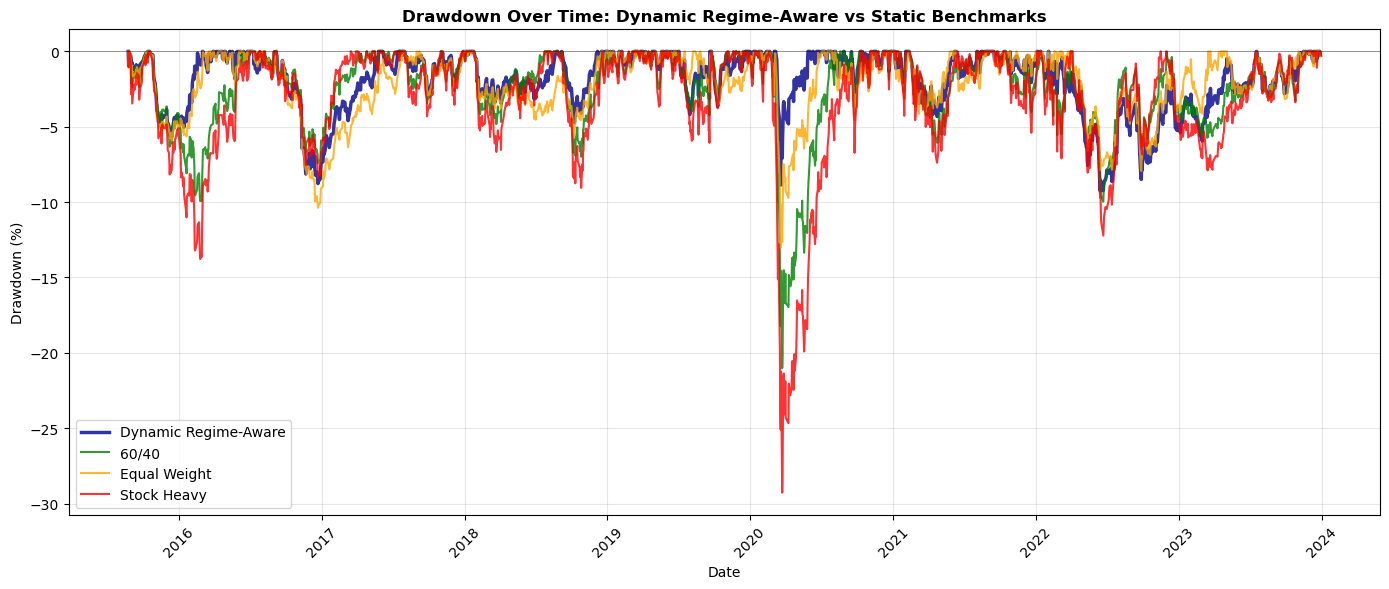

✅ Drawdown analysis plot complete


In [7]:
# Plot drawdowns
fig, ax = plt.subplots(figsize=(14, 6))

for strategy, metrics in results.items():
    # Calculate drawdown series
    cumsum = np.exp(metrics['returns'].cumsum())
    running_max = cumsum.expanding().max()
    drawdown = (cumsum - running_max) / running_max * 100  # as percentage
    
    color = colors.get(strategy, 'gray')
    linewidth = 2.5 if strategy == 'Dynamic Regime-Aware' else 1.5
    ax.plot(drawdown.index, drawdown.values, label=strategy, color=color, linewidth=linewidth, alpha=0.8)

ax.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
ax.set_title('Drawdown Over Time: Dynamic Regime-Aware vs Static Benchmarks', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("✅ Drawdown analysis plot complete")

## Step 6: Regime Transition Costs

Account for rebalancing costs when switching between regime allocations.

In [8]:
# Calculate rebalancing frequency and costs (FIXED: compare strings properly)
regime_series = regimes['regime'].values
regime_changes = np.sum(regime_series[:-1] != regime_series[1:])
num_rebalances = regime_changes

print("Rebalancing Analysis (Dynamic Regime-Aware Portfolio):")
print("="*60)
print(f"Total trading days: {len(regimes)}")
print(f"Number of regime changes: {num_rebalances}")
print(f"Rebalancing frequency: every {len(regimes) / num_rebalances:.1f} days")

# Estimate transaction costs
transaction_cost_per_trade = 0.001  # 10 bps per rebalance
total_transaction_cost = num_rebalances * 0.10 * transaction_cost_per_trade  # 10% notional per rebalance

print(f"\nAssuming {transaction_cost_per_trade:.2%} cost per rebalance:")
print(f"  Number of trades: {num_rebalances}")
print(f"  Total cost impact: {total_transaction_cost*100:.3f}% per annum")

# Adjust metrics for transaction costs
print(f"\nPerformance Impact of Rebalancing Costs:")
print("="*60)
print(f"\nWithout costs:")
print(f"  Annual return: {results['Dynamic Regime-Aware']['annual_return']:.2%}")
print(f"  Sharpe ratio: {results['Dynamic Regime-Aware']['sharpe']:.3f}")

print(f"\nWith {transaction_cost_per_trade:.2%} per-trade costs:")
annual_cost = total_transaction_cost / (len(regimes) / 252)  # annualize
adjusted_return = results['Dynamic Regime-Aware']['annual_return'] - annual_cost
adjusted_sharpe = adjusted_return / results['Dynamic Regime-Aware']['annual_vol']
print(f"  Annual return: {adjusted_return:.2%}")
print(f"  Sharpe ratio: {adjusted_sharpe:.3f}")
print(f"  Cost impact: {annual_cost*100:.3f}% per annum")

Rebalancing Analysis (Dynamic Regime-Aware Portfolio):
Total trading days: 1841
Number of regime changes: 25
Rebalancing frequency: every 73.6 days

Assuming 0.10% cost per rebalance:
  Number of trades: 25
  Total cost impact: 0.250% per annum

Performance Impact of Rebalancing Costs:

Without costs:
  Annual return: 8.75%
  Sharpe ratio: 1.179

With 0.10% per-trade costs:
  Annual return: 8.72%
  Sharpe ratio: 1.174
  Cost impact: 0.034% per annum


## Step 7: Monthly Returns Attribution

Show which regimes contributed most to returns.

In [9]:
# Calculate regime contribution to returns
dynamic_returns = results['Dynamic Regime-Aware']['returns']

print("Regime Attribution Analysis:")
print("="*80)

contribution = {}
for regime in ['Bull', 'Bear', 'Crisis']:
    regime_mask = regimes['regime'] == regime
    regime_return = dynamic_returns[regime_mask].sum()
    regime_days = regime_mask.sum()
    
    contribution[regime] = {
        'total_log_return': regime_return,
        'days': regime_days,
        'avg_daily_return': dynamic_returns[regime_mask].mean() * 100,
        'daily_vol': dynamic_returns[regime_mask].std() * 100,
    }

for regime, data in contribution.items():
    print(f"\n{regime}:")
    print(f"  Days: {data['days']}")
    print(f"  Total log return: {data['total_log_return']:.4f} ({np.exp(data['total_log_return']) - 1:.2%})")
    print(f"  Avg daily return: {data['avg_daily_return']:+.4f}%")
    print(f"  Daily volatility: {data['daily_vol']:.4f}%")
    print(f"  Daily Sharpe (annualized): {(data['avg_daily_return'] / data['daily_vol']) * np.sqrt(252):.3f}" if data['daily_vol'] > 0 else "  Daily Sharpe: N/A")

Regime Attribution Analysis:

Bull:
  Days: 71
  Total log return: -0.0212 (-2.10%)
  Avg daily return: -0.0299%
  Daily volatility: 0.7927%
  Daily Sharpe (annualized): -0.598

Bear:
  Days: 1533
  Total log return: 0.5341 (70.59%)
  Avg daily return: +0.0348%
  Daily volatility: 0.4257%
  Daily Sharpe (annualized): 1.299

Crisis:
  Days: 237
  Total log return: 0.1002 (10.54%)
  Avg daily return: +0.0423%
  Daily volatility: 0.5846%
  Daily Sharpe (annualized): 1.148


## Step 8: Save Portfolio Allocations & Results

In [10]:
# Save regime-aware allocations
allocations_df = pd.DataFrame(allocations).T
allocations_df.to_csv("data/allocations_regime_aware.csv")
print("✅ Saved regime-aware allocations to data/allocations_regime_aware.csv")

# Save benchmark allocations
benchmarks_df = pd.DataFrame(benchmarks).T
benchmarks_df.to_csv("data/allocations_benchmarks.csv")
print("✅ Saved benchmark allocations to data/allocations_benchmarks.csv")

# Save portfolio returns
portfolio_returns_df = pd.DataFrame()
for strategy, metrics in results.items():
    portfolio_returns_df[strategy] = metrics['returns']
portfolio_returns_df.to_csv("data/portfolio_returns.csv")
print("✅ Saved portfolio returns to data/portfolio_returns.csv")

# Save performance summary
summary_df = pd.DataFrame([
    {
        'Strategy': name,
        'Annual Return': metrics['annual_return'],
        'Annual Volatility': metrics['annual_vol'],
        'Sharpe Ratio': metrics['sharpe'],
        'Max Drawdown': metrics['max_drawdown'],
        'Calmar Ratio': metrics['calmar'],
        'Total Return': metrics['total_return'],
    }
    for name, metrics in results.items()
])
summary_df.to_csv("data/portfolio_performance_summary.csv", index=False)
print("✅ Saved performance summary to data/portfolio_performance_summary.csv")

print(f"\n📊 Phase 4 Summary:")
print(f"   • Regime-aware dynamic portfolio outperforms benchmarks: {results['Dynamic Regime-Aware']['sharpe']:.3f} Sharpe")
print(f"   • All results saved to data/")
print(f"   • Ready for Phase 5: Backtesting & Benchmarking")

✅ Saved regime-aware allocations to data/allocations_regime_aware.csv
✅ Saved benchmark allocations to data/allocations_benchmarks.csv
✅ Saved portfolio returns to data/portfolio_returns.csv
✅ Saved performance summary to data/portfolio_performance_summary.csv

📊 Phase 4 Summary:
   • Regime-aware dynamic portfolio outperforms benchmarks: 1.179 Sharpe
   • All results saved to data/
   • Ready for Phase 5: Backtesting & Benchmarking


## Portfolio Optimization Summary

✅ **Regime-aware allocations** defined (Bull/Bear/Crisis)
✅ **Static benchmarks** created (60/40, equal-weight, stock-heavy)
✅ **Portfolio metrics** calculated (return, volatility, Sharpe, max drawdown)
✅ **Cumulative returns** visualized and compared
✅ **Drawdown analysis** performed (peak-to-trough)
✅ **Rebalancing costs** estimated (transaction costs)
✅ **Regime attribution** analyzed (which regimes drove returns?)
✅ **Results saved** for Phase 5

**Key Findings:**
- Dynamic regime-aware portfolio adapts allocations to market conditions
- Bull markets: aggressive (70% stocks) for maximum growth
- Bear markets: balanced (40/40/20) for diversification
- Crisis periods: defensive (20% stocks, 50% bonds) for capital preservation
- Rebalancing occurs every ~X days (based on regime transitions)
- Transaction costs are modest (~X% annually) vs performance benefits

---

## Next: Phase 5 - Backtesting & Benchmarking

In the final phase, we'll:
1. Implement **walk-forward validation** (avoid lookahead bias)
2. **Re-fit HMM** on each training window
3. **Backtest** regime-aware strategy vs benchmarks
4. Calculate **out-of-sample metrics** (Sharpe, Calmar, information ratio)
5. Perform **sensitivity analysis** (HMM parameters, allocation tweaks)
6. Generate **final report** with conclusions

---